# VarAnneal Tutorial

## Introduction
VarAnneal is a Python package for state and parameter estimation in partially observed dynamical systems and neural networks.  It uses variational annealing (VA), a variational data assimilation method.  VarAnneal is hosted on GitHub at [github.com/paulrozdeba/varanneal](http://github.com/paulrozdeba/varanneal).

In variational data assimilation, statistical path estimates conditioned on observational data are calculated using high-dimensional integrals of the form:
$$
\mathrm{E}\left[G(X) \lvert Y\right] = \frac{\int dX \: G(X)\: e^{-A(X,Y)}}{\int dX \: e^{-A(X,Y)}} \equiv \frac{1}{\mathcal{Z}(Y)} \int dX \: G(X)\: e^{-A(X,Y)}
$$
where $X$ is a vector of model states and parameters, and $Y$ is a vector of observational data.  These integrals may be approximated using Laplace's method around the dominant peaks of $P(X\lvert Y)$.  VA uses an annealing-like, numerical continuation method for finding these peaks using numerical optimization.  This optimization is carried out using one of a variety of methods, such as L-BFGS-B, NCG, IPOPT (future), ...   These methods require derivatives of $A$, which are computed with automatic differentiation (AD) using the PYADOLC wrapper around ADOL-C.

In dynamical systems, this amounts to estimating statistics for model parameters, as well as trajectories of model states, like the mode, mean, variance, ...  The data consists of time series of partial observations of the model variables.

In neural networks, this is used as a method of training the network weights on labeled data sets.

---

## Reusing Paul's sample code for a RNN

In [1]:
# Necessary package imports
import time
import numpy as np
%matplotlib nbagg
import matplotlib.pyplot as plt

In [2]:
from varanneal import va_nnet

#### Define the activation function

In [3]:
def sigmoid(x, W, b):
    linpart = np.dot(W, x) + b
    return 1.0 / (1.0 + np.exp(-linpart))

#### Network structure

In [4]:
N = 3  # Total number of layers
D_in = 3  # Number of neurons in the input layer
D_out = 4  # Number of neurons in the output layer
D_hidden = 20  # Number of neurons in the hidden layers

## look at the dynamical range of the output
## add 1% or 2% noise to input data

# Network structure is stored in a list, where element i is the number 
# of neurons in layer i.
structure = np.zeros(N, dtype='int')
structure[0] = D_in  # 3 neurons in the input layer
structure[N-1] = D_out  # 2 neurons in the output layer
for i in range(1, N-1):
    structure[i] = D_hidden  # 5 neurons in the hidden layers

Lidx = [np.linspace(0, D_in-1, D_in, dtype='int'), np.linspace(0, D_out-1, D_out, dtype='int')]

#### Action/annealing parameters

In [73]:
# RM, RF0
RM = 1.0
RF0 = 1.0e-8 * RM * float(np.sum(structure) - structure[0]) / float(structure[0] + structure[-1])
g0 = RF0 / RM

# alpha, and beta ladder
alpha = 1.1
beta_array = np.linspace(0, 435, 436)
#beta_array = np.linspace(0, 100, 101)
gammas_all = g0 * alpha**beta_array

#### Load data set (3 in, 4 out)

In [99]:
M = 2000 # number of training examples
# need more training examples

data = np.load('l96/data/l96_data_N5.npy') # has 5 l96 variables
data = data[0:M+D_in+D_out,:]
Didx = 0

# normalize
data = data / np.max(np.abs(data))

#add noise
noise = np.random.normal(scale=0.02, size=data.shape[0])
data[:, Didx] += noise

T = data.shape[0]

data_in = np.zeros((M, D_in))
data_out = np.zeros((M, D_out))

for i in xrange(M):
    data_in[i] = data[i:i+D_in, Didx]
    data_out[i] = data[i+D_in:i+D_in+D_out, Didx]

#### Plot Data

<IPython.core.display.Javascript object>


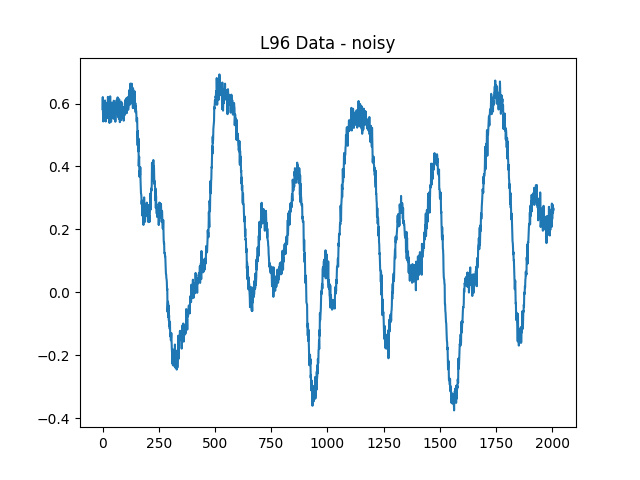

In [100]:
plt.figure()
plt.plot(data[:,0])
plt.title("L96 Data - noisy")
plt.savefig("L96 Train Set - noisy")
plt.show()

#### Initial neuron activation/weight guesses

In [104]:
np.random.seed(27509436)

# Neuron states
Xin = np.random.randn(D_in)
Xin = (Xin - np.average(Xin)) / np.std(Xin)
X0 = np.copy(Xin)

for n in xrange(N-2):
    X0 = np.append(X0, 0.2*np.random.rand(D_hidden) + 0.4)
X0 = np.append(X0, 0.2*np.random.rand(D_out) + 0.4)

for m in xrange(M - 1):
    Xin = np.random.randn(D_in)
    Xin = (Xin - np.average(Xin)) / np.std(Xin)
    X0 = np.append(X0, Xin)
    for n in xrange(N-2):
        X0 = np.append(X0, 0.2*np.random.rand(D_hidden) + 0.4)
    X0 = np.append(X0, 0.2*np.random.rand(D_out) + 0.4)

X0 = np.array(X0).flatten()

# Parameters
NP = np.sum(structure[1:]*structure[:-1] + structure[1:])
P0 = np.array([], dtype=np.float64)

W_i0 = 0
W_if = structure[0]*structure[1]
b_i0 = W_if
b_if = b_i0 + structure[1]

# Set up Pidx so that only weights, not biases, are estimated
for n in xrange(N - 1):
    if n == 0:
        Pidx = np.arange(W_i0, W_if, 1, dtype='int')
    else:
        Pidx = np.append(Pidx, np.arange(W_i0, W_if, 1, dtype='int'))
    if n == 0:
        P0 = np.append(P0, (2.0*np.random.rand(structure[n]*structure[n+1]) - 1.0) / D_in)
    else:
        P0 = np.append(P0, (2.0*np.random.rand(structure[n]*structure[n+1]) - 1.0) / D_hidden)
    P0 = np.append(P0, np.zeros(structure[n+1]))

    if n < N - 2:
        W_i0 = b_if
        W_if = W_i0 + structure[n+1]*structure[n+2]
        b_i0 = W_if
        b_if = b_i0 + structure[n+2]

P0 = np.array(P0).flatten()
Pidx = np.array(Pidx).flatten().tolist()

### Use VA to train the network weights

In [105]:
# Initialize Annealer
anneal1 = va_nnet.Annealer()
# Set the network structure
anneal1.set_structure(structure)
# Set the activation function
anneal1.set_activation(sigmoid)
# Set the input and output data
anneal1.set_input_data(data_in)
anneal1.set_output_data(data_out)

#### Run VA using L-BFGS-B

In [ ]:
BFGS_options = {'gtol':1.0e-12, 'ftol':1.0e-12, 'maxfun':1000000, 'maxiter':1000000}

tstart = time.time()
anneal1.anneal(X0, P0, alpha, beta_array, RM, RF0, Pidx, Lidx=Lidx,
               method='L-BFGS-B', opt_args=BFGS_options, adolcID=0)

print("\nADOL-C annealing completed in %f s."%(time.time() - tstart))

------------------------------
Step 1 of 436
beta = 0, RF = 3.42857143e-08

Taping action evaluation...
Done!
Time = 3.7882938385 s

Beginning optimization...
Optimization complete!
Time = 2.49603700638 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 4
Obj. function value = [  5.06354279e-10]

------------------------------
Step 2 of 436
beta = 1, RF = 3.77142857e-08

Taping action evaluation...
Done!
Time = 2.88559508324 s

Beginning optimization...
Optimization complete!
Time = 0.879224061966 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 1
Obj. function value = [  5.56941387e-10]

------------------------------
Step 3 of 436
beta = 2, RF = 4.14857143e-08

Taping action evaluation...
Done!
Time = 4.40663695335 s

Beginning optimization...
Optimization complete!
Time = 1.35940313339 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 1
Obj. function value = [  

Taping action evaluation...
Done!
Time = 2.4814081192 s

Beginning optimization...
Optimization complete!
Time = 1.23466801643 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 1
Obj. function value = [  4.98621057e-09]

------------------------------
Step 26 of 436
beta = 25, RF = 3.71475632e-07

Taping action evaluation...
Done!
Time = 2.18956708908 s

Beginning optimization...
Optimization complete!
Time = 1.005204916 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 1
Obj. function value = [  5.48481259e-09]

------------------------------
Step 27 of 436
beta = 26, RF = 4.08623196e-07

Taping action evaluation...
Done!
Time = 2.40145802498 s

Beginning optimization...
Optimization complete!
Time = 0.990134954453 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 1
Obj. function value = [  6.03327219e-09]

------------------------------
Step 28 of 436
beta = 27, 

Done!
Time = 2.50685691833 s

Beginning optimization...
Optimization complete!
Time = 1.17330694199 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 1
Obj. function value = [  4.91027163e-08]

------------------------------
Step 50 of 436
beta = 49, RF = 3.65893567e-06

Taping action evaluation...
Done!
Time = 2.24890208244 s

Beginning optimization...
Optimization complete!
Time = 1.85984706879 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 4
Obj. function value = [  5.28646246e-08]

------------------------------
Step 51 of 436
beta = 50, RF = 4.02482924e-06

Taping action evaluation...
Done!
Time = 2.34211206436 s

Beginning optimization...
Optimization complete!
Time = 1.46282815933 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 1
Obj. function value = [  5.81507530e-08]

------------------------------
Step 52 of 436
beta = 51, RF = 4.42731217e-06

Tapin

Optimization complete!
Time = 0.888051986694 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 1
Obj. function value = [  4.22403784e-08]

------------------------------
Step 74 of 436
beta = 73, RF = 3.60395383e-05

Taping action evaluation...
Done!
Time = 2.1760468483 s

Beginning optimization...
Optimization complete!
Time = 5.06128716469 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 26
Obj. function value = [  4.56713844e-08]

------------------------------
Step 75 of 436
beta = 74, RF = 3.96434921e-05

Taping action evaluation...
Done!
Time = 2.26624107361 s

Beginning optimization...
Optimization complete!
Time = 0.784682035446 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 1
Obj. function value = [  5.02379984e-08]

------------------------------
Step 76 of 436
beta = 75, RF = 4.36078413e-05

Taping action evaluation...
Done!
Time = 2.29894089699 s

B

Optimization complete!
Time = 39.4781749249 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 323
Obj. function value = [  3.67400706e-07]

------------------------------
Step 98 of 436
beta = 97, RF = 3.54979818e-04

Taping action evaluation...
Done!
Time = 2.17918586731 s

Beginning optimization...
Optimization complete!
Time = 5.96824598312 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 40
Obj. function value = [  4.03789173e-07]

------------------------------
Step 99 of 436
beta = 98, RF = 3.90477799e-04

Taping action evaluation...
Done!
Time = 2.31314897537 s

Beginning optimization...
Optimization complete!
Time = 1.23640799522 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 1
Obj. function value = [  4.44163312e-07]

------------------------------
Step 100 of 436
beta = 99, RF = 4.29525579e-04

Taping action evaluation...
Done!
Time = 2.30525398254 s


...

Optimization complete!
Time = 1.83895897865 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 3
Obj. function value = [  3.25040243e-05]

------------------------------
Step 146 of 436
beta = 145, RF = 3.44391600e-02

Taping action evaluation...
Done!
Time = 2.58860182762 s

Beginning optimization...
Optimization complete!
Time = 1.47026586533 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 2
Obj. function value = [  3.57221600e-05]

------------------------------
Step 147 of 436
beta = 146, RF = 3.78830760e-02

Taping action evaluation...
Done!
Time = 2.73314595222 s

Beginning optimization...
Optimization complete!
Time = 1.96332001686 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 3
Obj. function value = [  3.92554074e-05]

------------------------------
Step 148 of 436
beta = 147, RF = 4.16713836e-02

Taping action evaluation...
Done!
Time = 2.49391293526 

Done!
Time = 2.52770113945 s

Beginning optimization...
Optimization complete!
Time = 18.5254721642 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 135
Obj. function value = [ 0.00032333]

------------------------------
Step 171 of 436
beta = 170, RF = 3.73138171e-01

Taping action evaluation...
Done!
Time = 2.36202716827 s

Beginning optimization...
Optimization complete!
Time = 2.73214697838 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 13
Obj. function value = [ 0.0003525]

------------------------------
Step 172 of 436
beta = 171, RF = 4.10451988e-01

Taping action evaluation...
Done!
Time = 2.42929816246 s

Beginning optimization...
Optimization complete!
Time = 17.3814389706 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 128
Obj. function value = [ 0.00038399]

------------------------------
Step 173 of 436
beta = 172, RF = 4.51497187e-01

Taping act

Optimization complete!
Time = 79.8110361099 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 520
Obj. function value = [ 0.00177212]

------------------------------
Step 195 of 436
beta = 194, RF = 3.67531124e+00

Taping action evaluation...
Done!
Time = 5.66167902946 s

Beginning optimization...
Optimization complete!
Time = 74.4801039696 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 470
Obj. function value = [ 0.00185777]

------------------------------
Step 196 of 436
beta = 195, RF = 4.04284236e+00

Taping action evaluation...
Done!
Time = 3.88075399399 s

Beginning optimization...
Optimization complete!
Time = 82.2981131077 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 555
Obj. function value = [ 0.00194316]

------------------------------
Step 197 of 436
beta = 196, RF = 4.44712660e+00

Taping action evaluation...
Done!
Time = 3.19541597366 s

Beginn

Taping action evaluation...
Done!
Time = 2.77432012558 s

Beginning optimization...
Optimization complete!
Time = 125.858161926 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 1058
Obj. function value = [ 0.00329043]

------------------------------
Step 220 of 436
beta = 219, RF = 3.98209165e+01

Taping action evaluation...
Done!
Time = 2.76100087166 s

Beginning optimization...
Optimization complete!
Time = 114.885592937 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 1003
Obj. function value = [ 0.00331748]

------------------------------
Step 221 of 436
beta = 220, RF = 4.38030082e+01

Taping action evaluation...
Done!
Time = 2.25926589966 s

Beginning optimization...
Optimization complete!
Time = 115.495666981 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 1022
Obj. function value = [ 0.0033426]

------------------------------
Step 222 of 436
beta = 221,

Taping action evaluation...
Done!
Time = 2.41890597343 s

Beginning optimization...
Optimization complete!
Time = 1219.68123007 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 8620
Obj. function value = [ 0.00360777]

------------------------------
Step 244 of 436
beta = 243, RF = 3.92225382e+02

Taping action evaluation...
Done!
Time = 3.08520078659 s

Beginning optimization...
Optimization complete!
Time = 258.036142826 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 1769
Obj. function value = [ 0.00361365]

------------------------------
Step 245 of 436
beta = 244, RF = 4.31447921e+02

Taping action evaluation...
Done!
Time = 2.44292998314 s

Beginning optimization...
Optimization complete!
Time = 324.950451851 s
Exit flag = 0
Exit message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations = 2229
Obj. function value = [ 0.00361934]

------------------------------
Step 246 of 436
beta = 245

#### Save the output

In [82]:
anneal1.save_io("l96/results/io.npy")
anneal1.save_Wb("l96/results/W.npy", "l96/results/b.npy")
anneal1.save_action_errors("l96/results/action_errors.npy")

### Plot the results

In [ ]:
# Load action curves
aerr = np.load("l96/results/action_errors.npy")
params = np.load("l96/results/params.npy")

<IPython.core.display.Javascript object>


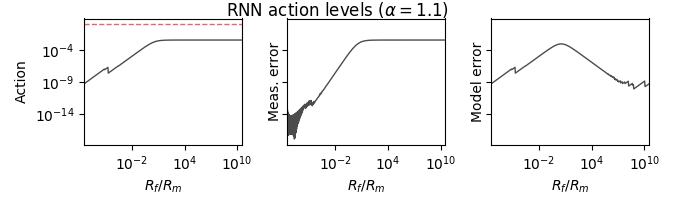

In [86]:
fig,ax = plt.subplots(1, 3, figsize=(6.75, 2.1), sharey=True)
fig.set_tight_layout(True)

ymin = 1.0e20
ymax = 0.0

plotlw = 1.0
plotalpha = .7
#plotcolors = ["C0", "C0", "C0"]
plotcolors = ["black", "black", "black"]

action_vals = aerr[:, 1]
ax[0].plot(gammas_all[:], action_vals, lw=plotlw, color=plotcolors[0], alpha=plotalpha)
ax[0].set_xlabel(r"$R_f/R_m$")
ax[0].set_ylabel("Action")
ax[0].axhline(y=1, lw=1, ls="--", color="C3", alpha=.7)

measerr_vals = aerr[:, 2]
ax[1].plot(gammas_all[:], measerr_vals, lw=plotlw, color=plotcolors[1], alpha=plotalpha)
ax[1].set_xlabel(r"$R_f/R_m$")
ax[1].set_ylabel("Meas. error")

moderr_vals = aerr[:, 3]
ax[2].plot(gammas_all[:], moderr_vals, lw=plotlw, color=plotcolors[2], alpha=plotalpha)
ax[2].set_xlabel(r"$R_f/R_m$")
ax[2].set_ylabel("Model error")

fig.suptitle("RNN action levels ($\\alpha = 1.1$)", y=1.0)

for i in range(3):
    ax[i].set_yscale('log')
    ax[i].set_xscale('log')
    ax[i].set_xlim(gammas_all[0], gammas_all[-1])
    #ax[i].set_ylim(.001, 1.0e2)
plt.savefig("RNN L96 Action Levels - noisy")
plt.show()

#### Parameter estimates

In [53]:
#structure = np.array([25, 3, 4])
Nbias = np.sum(structure[1:])
Nweight = np.sum(structure[1:] * structure[:-1])

sortedp = []

West = np.load("l96/results/W.npy")
best = np.load("l96/results/b.npy")

for i in xrange(len(gammas_all)):
    #West = np.load("W.npy")
    #best = np.load("b.npy")
    for j, West_n in enumerate(West[i]):
        if j == 0:
            pest = West_n.flatten()#, best_n.flatten())
        else:
            pest = np.append(pest, West_n.flatten())
    for j, best_n in enumerate(best[i]):
        pest = np.append(pest, best_n.flatten())
    sortedp.append(pest.flatten())

sortedp = np.array(sortedp)

In [45]:
fig,ax = plt.subplots(1, 1, figsize=(5,4))
fig.set_tight_layout(True)

nrange = range(Nweight + Nbias)
surf = ax.pcolormesh(gammas_all, nrange, np.abs(sortedp.T), rasterized=True, cmap='jet', norm=mplcolors.LogNorm())#, vmin=1.0E-7, vmax=1.0E3)
#surf = ax.pcolormesh(g, nrange, sortedp.T, rasterized=True, cmap='jet')#, norm=mplcolors.LogNorm())
ax.set_xscale("log")
ax.set_xlabel(r"$R_f/R_m$")
ax.set_ylabel(r"Parameter metaindex")
cbar = fig.colorbar(surf, ax=ax)
cbar.set_label(r"$W$")
ax.set_xlim((gammas_all[0], gammas_all[-1]))
ax.set_ylim((nrange[0], nrange[-1]))
#ax.set_title("Est. err. vs. data, sec%d mem%d"%(secID, ensID))

plt.show()
#fig.savefig("/home/prozdeba/Desktop/plots_20170801/nnet/params_M%d.pdf"%(Ntraining,))
#plt.close()

<IPython.core.display.Javascript object>

NameError: name 'mplcolors' is not defined

### Generate Some Plots